In [3]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y dataset')

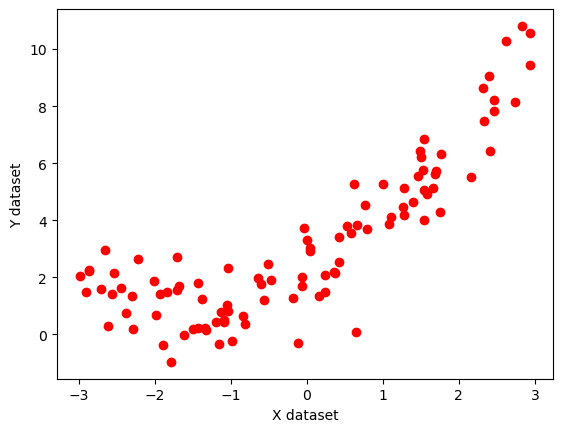

In [4]:
# Copying the below 2 lines of codes from numpy, which will help me create my dataset
X= 6* np.random.rand(100, 1) -3
y= 0.5 *X**2 + 1.5*X +2 + np.random.randn(100, 1)
# quadratic equation used : y=0.5x^2 +1.5x + 2 + outliers

plt.scatter(X, y, color='r')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [5]:
# train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
## Let's implement SimpleLinear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [7]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import r2_score

y_pred = regression.predict(X_test)
score = r2_score(y_test, y_pred)
print(score)

0.7760662849043922


Text(0, 0.5, 'Y')

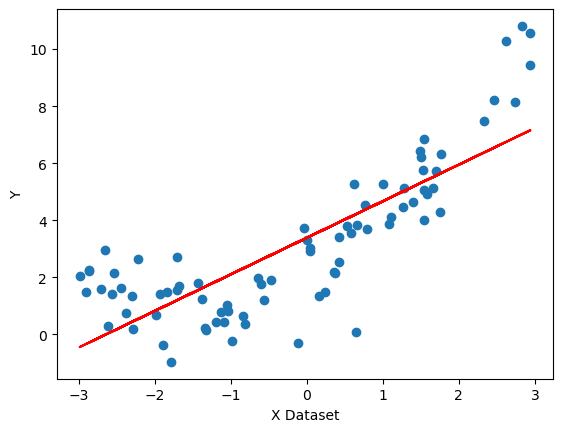

In [9]:
## Let's visualise this model
plt.plot(X_train,regression.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel('X Dataset')
plt.ylabel('Y')

In [10]:
# Let's apply ploynimial transformation
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)

In [11]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [12]:
X_train_poly
##     bias           x^1 feature          x^ feature

array([[ 1.00000000e+00,  1.69919518e+00,  2.88726426e+00],
       [ 1.00000000e+00, -2.43723081e+00,  5.94009404e+00],
       [ 1.00000000e+00, -1.42870685e+00,  2.04120327e+00],
       [ 1.00000000e+00, -1.67761499e+00,  2.81439206e+00],
       [ 1.00000000e+00, -2.28001667e+00,  5.19847602e+00],
       [ 1.00000000e+00,  1.66152269e+00,  2.76065765e+00],
       [ 1.00000000e+00,  7.88436746e-01,  6.21632503e-01],
       [ 1.00000000e+00, -1.04257360e+00,  1.08695971e+00],
       [ 1.00000000e+00, -8.35664296e-01,  6.98334815e-01],
       [ 1.00000000e+00, -1.70101062e+00,  2.89343713e+00],
       [ 1.00000000e+00, -1.19177044e+00,  1.42031677e+00],
       [ 1.00000000e+00, -2.85835665e+00,  8.17020275e+00],
       [ 1.00000000e+00, -2.64627519e+00,  7.00277236e+00],
       [ 1.00000000e+00, -1.32541668e+00,  1.75672938e+00],
       [ 1.00000000e+00, -4.75593043e-01,  2.26188742e-01],
       [ 1.00000000e+00,  1.26593612e+00,  1.60259426e+00],
       [ 1.00000000e+00, -1.37841170e+00

In [13]:
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)
# so the R-square value has significantly imcreased
# before it was 59% now it's 83%

0.9041509601889559


In [14]:
print(regression.coef_)

[[0.         1.43199152 0.46807786]]


In [15]:
print(regression.intercept_)

[2.06899801]


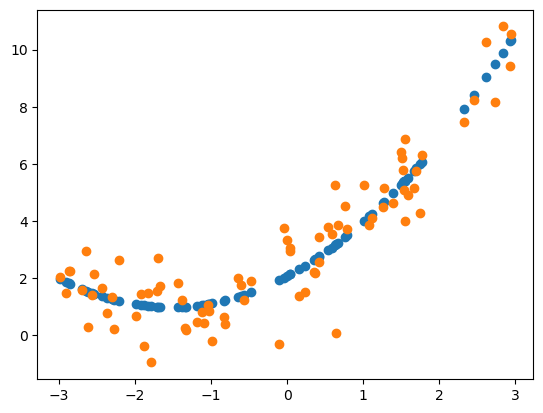

In [16]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

# Now let's check what will happen if I make the ploynomial degree = 3

In [17]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

X_train_poly  # Now we have 4 features

array([[ 1.00000000e+00,  1.69919518e+00,  2.88726426e+00,
         4.90602552e+00],
       [ 1.00000000e+00, -2.43723081e+00,  5.94009404e+00,
        -1.44773802e+01],
       [ 1.00000000e+00, -1.42870685e+00,  2.04120327e+00,
        -2.91628110e+00],
       [ 1.00000000e+00, -1.67761499e+00,  2.81439206e+00,
        -4.72146630e+00],
       [ 1.00000000e+00, -2.28001667e+00,  5.19847602e+00,
        -1.18526120e+01],
       [ 1.00000000e+00,  1.66152269e+00,  2.76065765e+00,
         4.58689531e+00],
       [ 1.00000000e+00,  7.88436746e-01,  6.21632503e-01,
         4.90117908e-01],
       [ 1.00000000e+00, -1.04257360e+00,  1.08695971e+00,
        -1.13323550e+00],
       [ 1.00000000e+00, -8.35664296e-01,  6.98334815e-01,
        -5.83573472e-01],
       [ 1.00000000e+00, -1.70101062e+00,  2.89343713e+00,
        -4.92176729e+00],
       [ 1.00000000e+00, -1.19177044e+00,  1.42031677e+00,
        -1.69269154e+00],
       [ 1.00000000e+00, -2.85835665e+00,  8.17020275e+00,
      

In [18]:
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9061735797440943


In [19]:
## Rediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

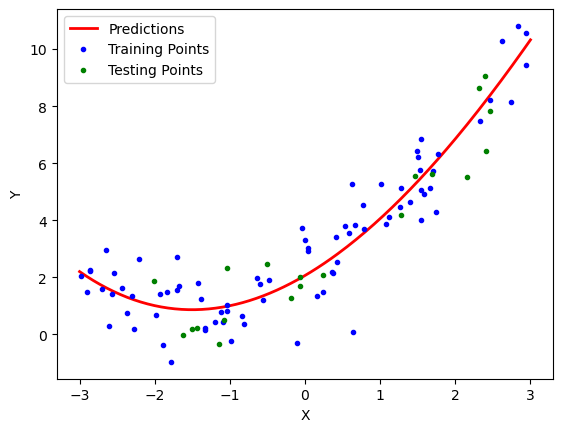

In [20]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new,"r-", linewidth=2, label='Predictions')
plt.plot(X_train, y_train,"b.", label='Training Points')
plt.plot(X_test, y_test,"g.", label='Testing Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()